# 04 · Uncertainty & sensitivity

Two robustness questions:

1. **Duration uncertainty (ζ).** Real schedulers don't know exact task durations.
   `apply_duration_uncertainty` perturbs each runtime by Gaussian noise
   `ε ~ N(0, (ζ·d)²)`. How much does the deferability *decision* change vs the
   perfect-information baseline (ζ=0)? — measured with confusion matrices.
2. **Parameter sensitivity.** How does deferrable energy respond to the LAD-FLEX
   parameters (latency, flex window, β), via the `SENSITIVE` parameter sweep?

Everything is generated in-notebook from the base sample — no extra data files.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from lad_flex import *

sns.set_theme(style="whitegrid")
os.makedirs("outputs", exist_ok=True)

df = pd.read_csv("data/df_tasks_sample.csv", parse_dates=["start_time", "end_time"]).set_index("task_name")
df["t_request"] = df["start_time"] - pd.to_timedelta(df["wait_time"], unit="s")

ZETAS = [0.10, 0.20, 0.30, 0.50, 0.70]
perturbed = {z: apply_duration_uncertainty(df, z) for z in ZETAS}
print("perturbed task sets:", {z: len(v) for z, v in perturbed.items()})

perturbed task sets: {0.1: 100000, 0.2: 100000, 0.3: 100000, 0.5: 100000, 0.7: 100000}


## Prediction-error distributions

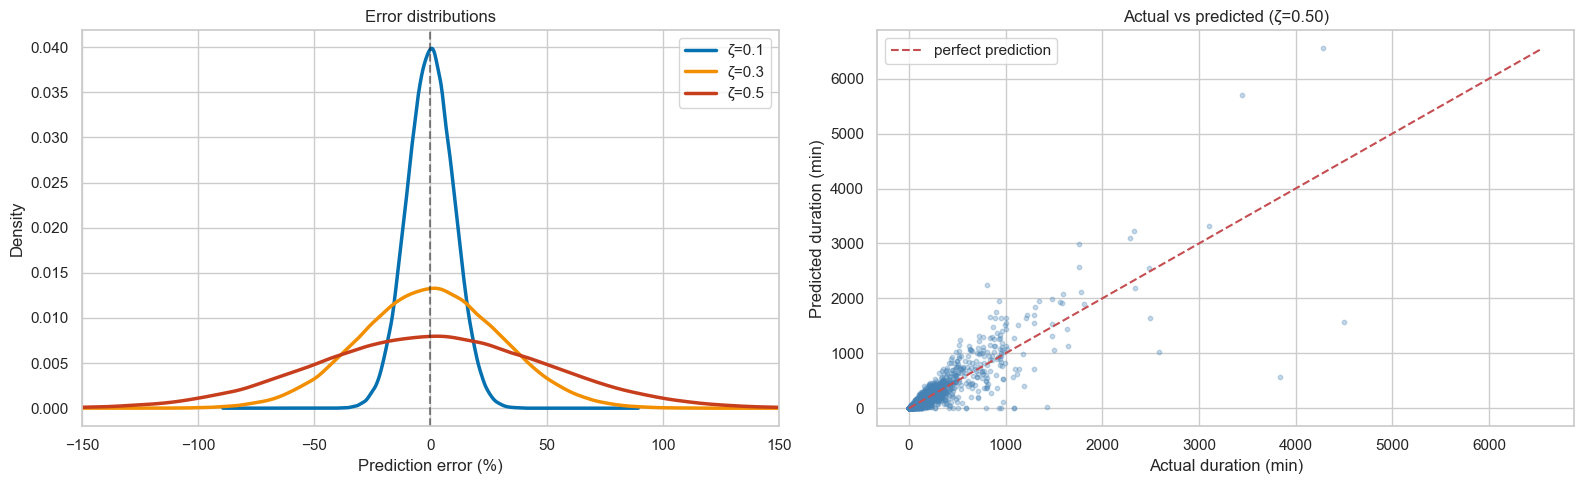

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for z, c in zip([0.10, 0.30, 0.50], ["#0571B0", "#F18F01", "#C73E1D"]):
    perturbed[z]["prediction_error_pct"].plot(kind="kde", ax=axes[0], color=c, lw=2.5, label=f"ζ={z}")
axes[0].axvline(0, color="k", ls="--", alpha=0.5)
axes[0].set_xlim(-150, 150); axes[0].set_xlabel("Prediction error (%)")
axes[0].set_title("Error distributions"); axes[0].legend()

samp = perturbed[0.50].sample(min(5000, len(df)), random_state=42)
axes[1].scatter(samp["duration_actual"] / 60, samp["duration_predicted"] / 60,
                s=10, alpha=0.3, color="steelblue")
m = max((samp["duration_actual"] / 60).max(), (samp["duration_predicted"] / 60).max())
axes[1].plot([0, m], [0, m], "r--", label="perfect prediction")
axes[1].set_xlabel("Actual duration (min)"); axes[1].set_ylabel("Predicted duration (min)")
axes[1].set_title("Actual vs predicted (ζ=0.50)"); axes[1].legend()
plt.tight_layout(); plt.savefig("outputs/uncertainty_error_dist.png", dpi=150); plt.show()

## Deferability under uncertainty (BASELINE)

Re-run LAD-FLEX over the sample week with perturbed durations for each ζ, then
compare task-level deferability decisions against the ζ=0 baseline.

In [3]:
SCEN = "BASELINE"
p = return_params("DEFAULT", SCEN)
mr = (max(p["delta_notifications"]) + max(p["flex_windows"]) + max(p["gamma_buffers"])).total_seconds()
sw = pd.date_range("1970-02-01", "1970-02-08", freq="h")

dpe0 = fast_power_energy_series(df, get_timeline(df))
_, res0 = run_lad_flex_sweep(df[df["runtime_i"] <= mr], dpe0, sw, p)
base = extract_task_decisions(res0)

res_by_zeta = {0: res0}
for z in ZETAS:
    dz = perturbed[z]
    dpe = fast_power_energy_series(dz, get_timeline(dz))
    _, rz = run_lad_flex_sweep(dz[dz["runtime_i"] <= mr], dpe, sw, p)
    res_by_zeta[z] = rz
print("sweeps complete for zeta:", list(res_by_zeta))

sweeps complete for zeta: [0, 0.1, 0.2, 0.3, 0.5, 0.7]


## Confusion matrices vs the ζ=0 baseline

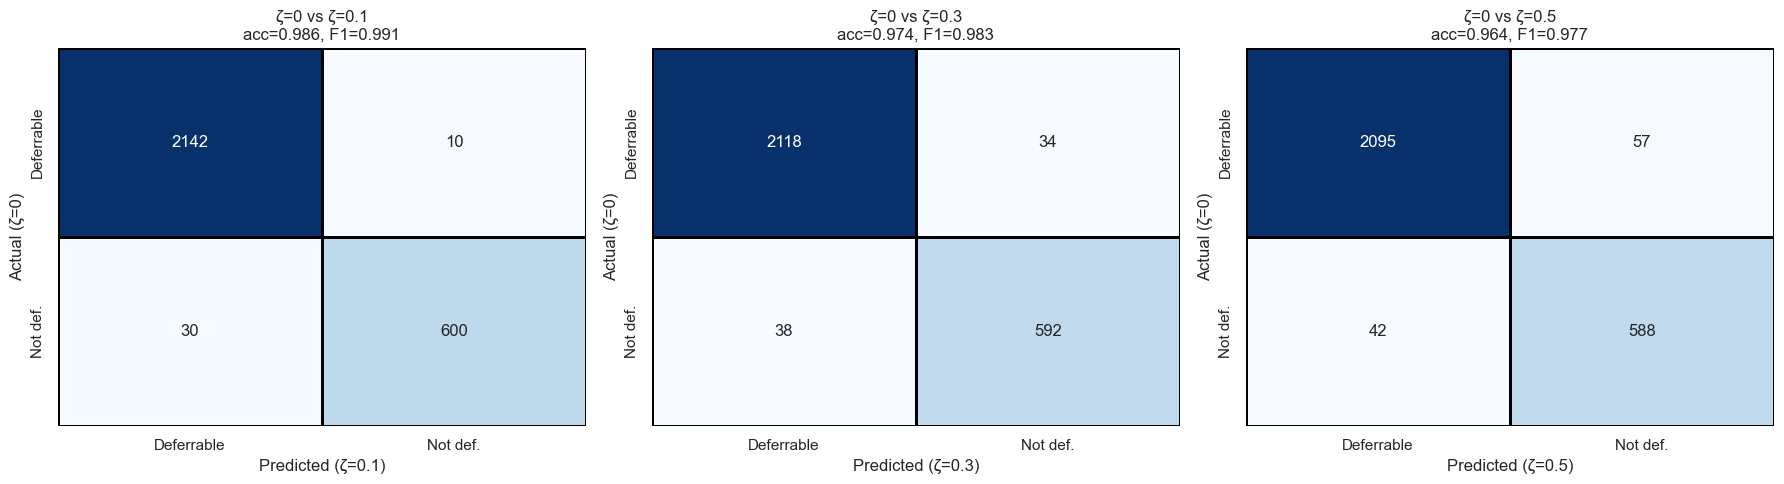

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, z in zip(axes, [0.10, 0.30, 0.50]):
    comp = extract_task_decisions(res_by_zeta[z])
    cm = build_confusion_matrix(base, comp)
    met = calculate_metrics(cm)
    arr = np.array([[cm["TP"], cm["FN"]], [cm["FP"], cm["TN"]]])
    sns.heatmap(arr, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                linewidths=2, linecolor="black")
    ax.set_title(f"ζ=0 vs ζ={z}\nacc={met['accuracy']:.3f}, F1={met['f1_score']:.3f}")
    ax.set_xticklabels(["Deferrable", "Not def."]); ax.set_yticklabels(["Deferrable", "Not def."], rotation=90)
    ax.set_xlabel(f"Predicted (ζ={z})"); ax.set_ylabel("Actual (ζ=0)")
plt.tight_layout(); plt.savefig("outputs/uncertainty_confusion.png", dpi=150); plt.show()

## Classification metrics vs ζ

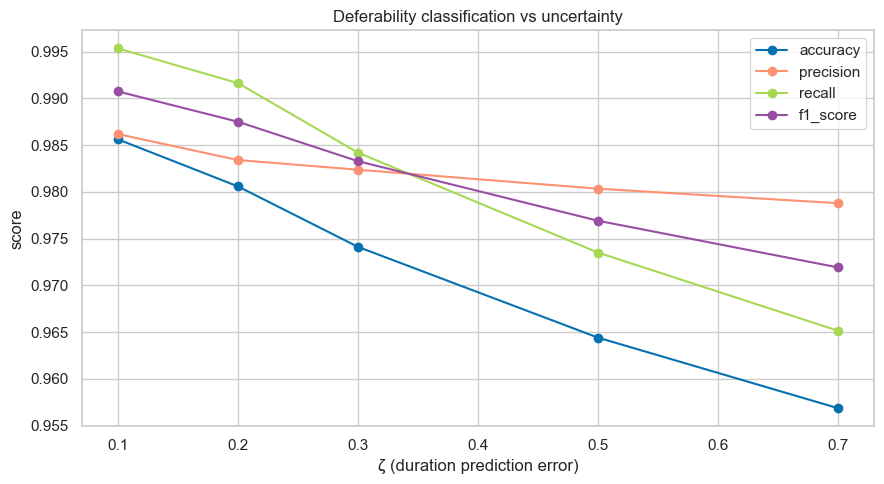

,accuracy,precision,recall,f1_score,specificity
zeta,,,,,
0.1,0.9856,0.9862,0.9954,0.9907,0.9524
0.2,0.9806,0.9834,0.9916,0.9875,0.9429
0.3,0.9741,0.9824,0.9842,0.9833,0.9397
0.5,0.9644,0.9803,0.9735,0.9769,0.9333
0.7,0.9569,0.9788,0.9651,0.9719,0.9286


In [5]:
rows = []
for z in ZETAS:
    comp = extract_task_decisions(res_by_zeta[z])
    met = calculate_metrics(build_confusion_matrix(base, comp))
    rows.append({"zeta": z, **met})
trend = pd.DataFrame(rows).set_index("zeta")

fig, ax = plt.subplots(figsize=(9, 5))
for col, c in zip(["accuracy", "precision", "recall", "f1_score"],
                  ["#0571B0", "#FC9272", "#A6D854", "#984ea3"]):
    ax.plot(trend.index, trend[col], "-o", color=c, label=col)
ax.set_xlabel("ζ (duration prediction error)"); ax.set_ylabel("score")
ax.set_title("Deferability classification vs uncertainty"); ax.legend()
plt.tight_layout(); plt.savefig("outputs/uncertainty_metrics_trend.png", dpi=150); plt.show()

trend.round(4).to_csv("outputs/uncertainty_metrics.csv")
trend.round(4)

## Parameter sensitivity (`SENSITIVE` sweep)

The `SENSITIVE` BASELINE configuration sweeps two latencies, two flex-window
lengths and two β values. We look at how mean deferrable energy responds.

In [6]:
psens = return_params("SENSITIVE", "BASELINE")
print("sweep grid:")
for k, v in psens.items():
    print(f"  {k}: {v}")

mr2 = (max(psens["delta_notifications"]) + max(psens["flex_windows"]) + max(psens["gamma_buffers"])).total_seconds()
ds_sens, _ = run_lad_flex_sweep(df[df["runtime_i"] <= mr2], dpe0, sw, psens)

agg = (ds_sens.groupby(["latency", "flex_window", "beta"])["deferrable_energy_kWh"]
       .mean().reset_index())
agg["flex_window_h"] = agg["flex_window"].dt.total_seconds() / 3600
agg.round(2)

sweep grid:
  latencies: [600, 900]
  flex_windows: [Timedelta('0 days 01:00:00'), Timedelta('0 days 02:00:00')]
  delta_notifications: [Timedelta('0 days 01:00:00')]
  betas: [0.5, 0.7]
  gamma_buffers: [Timedelta('0 days 01:00:00')]


,latency,flex_window,beta,deferrable_energy_kWh,flex_window_h
0,600,0 days 01:00:00,0.5,0.43,1.0
1,600,0 days 01:00:00,0.7,0.62,1.0
2,600,0 days 02:00:00,0.5,2.29,2.0
3,600,0 days 02:00:00,0.7,2.89,2.0
4,900,0 days 01:00:00,0.5,0.27,1.0
5,900,0 days 01:00:00,0.7,0.43,1.0
6,900,0 days 02:00:00,0.5,1.98,2.0
7,900,0 days 02:00:00,0.7,2.52,2.0


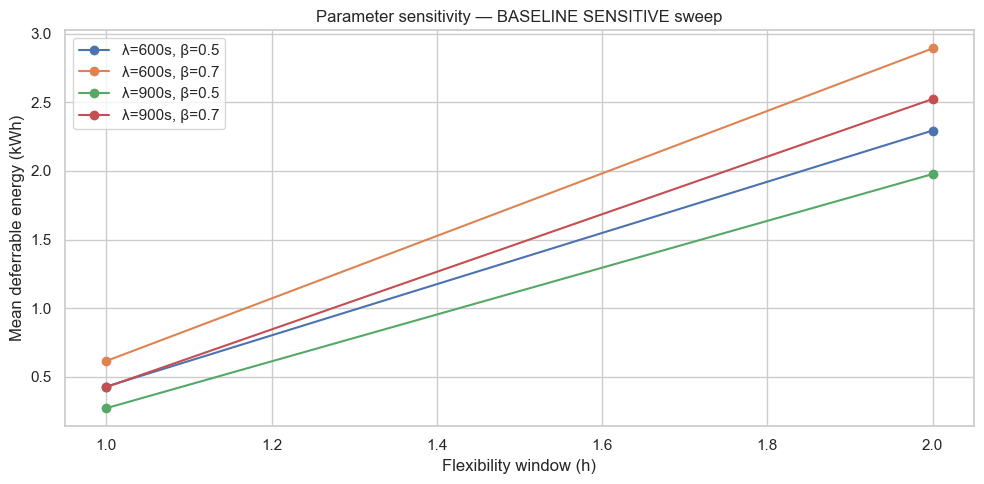

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
for (lat, beta), g in agg.groupby(["latency", "beta"]):
    ax.plot(g["flex_window_h"], g["deferrable_energy_kWh"], "-o", label=f"λ={lat}s, β={beta}")
ax.set_xlabel("Flexibility window (h)"); ax.set_ylabel("Mean deferrable energy (kWh)")
ax.set_title("Parameter sensitivity — BASELINE SENSITIVE sweep"); ax.legend()
plt.tight_layout(); plt.savefig("outputs/sensitivity_params.png", dpi=150); plt.show()

## Takeaways

- Classification accuracy **degrades as ζ grows** — duration mispredictions flip
  deferability decisions, mostly near the window edges (the β-overhang condition).
- Deferrable energy **increases with the flexibility window** and with a more
  permissive overhang tolerance β, and depends on the latency threshold.

This closes the showcase: EDA → method → scenario comparison → robustness.